**Magic strikes - Market**

# Imports

In [2]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import pandas as pd
from magic_strikes.swap import swap_market
import numpy as np
from magic_strikes.utils import relative_error

sns.set_theme("talk")
sns.set_style("whitegrid")
mpl.rcParams["figure.figsize"] = (8, 6)
SEED = 1234
SAVEFIG = False

In [16]:
### Dates used in the paper ###

# date = "20250210"
# date = "20250404"
# date = "20250407"
date = "20250702"


ivol_data = pd.read_csv(f"/Users/fbourgey/data/vol/{date}_spx_vol.csv", index_col=0)
# for now, we remove some outliers in the data for specific dates
# as they have a larger strike than the rest of the data (less strike coverage).

if date in ["20250404"]:
    ivol_data = ivol_data[ivol_data["Texp"] != 9.880e-01].copy()  # remove outlier
if date in ["20250407"]:
    ivol_data = ivol_data[ivol_data["Texp"] != 9.840e-01].copy()  # remove outlier
if date in ["20250702"]:
    ivol_data = ivol_data[
        ~ivol_data["Texp"].isin([7.480e-01, 9.960e-01])
    ].copy()  # remove outlier

expiries = ivol_data["Texp"].unique()

# Variance contract

In [17]:
# variance contract
res = swap_market(
    ivol_data=ivol_data,
    opt="variance",
    n_quad=10,
    extrapolation="flat",
    record_compute_time=True,
)


Expiry 0.0040: variance swap (Fukasawa) using n_quad=10.

Expiry 0.0040: variance swap (magic strikes).

Computing magic strikes for T=0.0040... (1/1)
Computing magic strikes for T=0.0040... (1/1)
Computing magic strikes for T=0.0040... (1/1)
Computing magic strikes for T=0.0040... (1/1)
Computing magic strikes for T=0.0040... (1/1)
Computing magic strikes for T=0.0040... (1/1)
Computing magic strikes for T=0.0040... (1/1)
Computing magic strikes for T=0.0040... (1/1)
Computing magic strikes for T=0.0040... (1/1)
Computing magic strikes for T=0.0040... (1/1)
Computing magic strikes for T=0.0040... (1/1)
Computing magic strikes for T=0.0040... (1/1)
Computing magic strikes for T=0.0040... (1/1)
Computing magic strikes for T=0.0040... (1/1)
Computing magic strikes for T=0.0040... (1/1)

Expiry 0.0080: variance swap (Fukasawa) using n_quad=10.

Expiry 0.0080: variance swap (magic strikes).

Computing magic strikes for T=0.0080... (1/1)
Computing magic strikes for T=0.0080... (1/1)
Comput

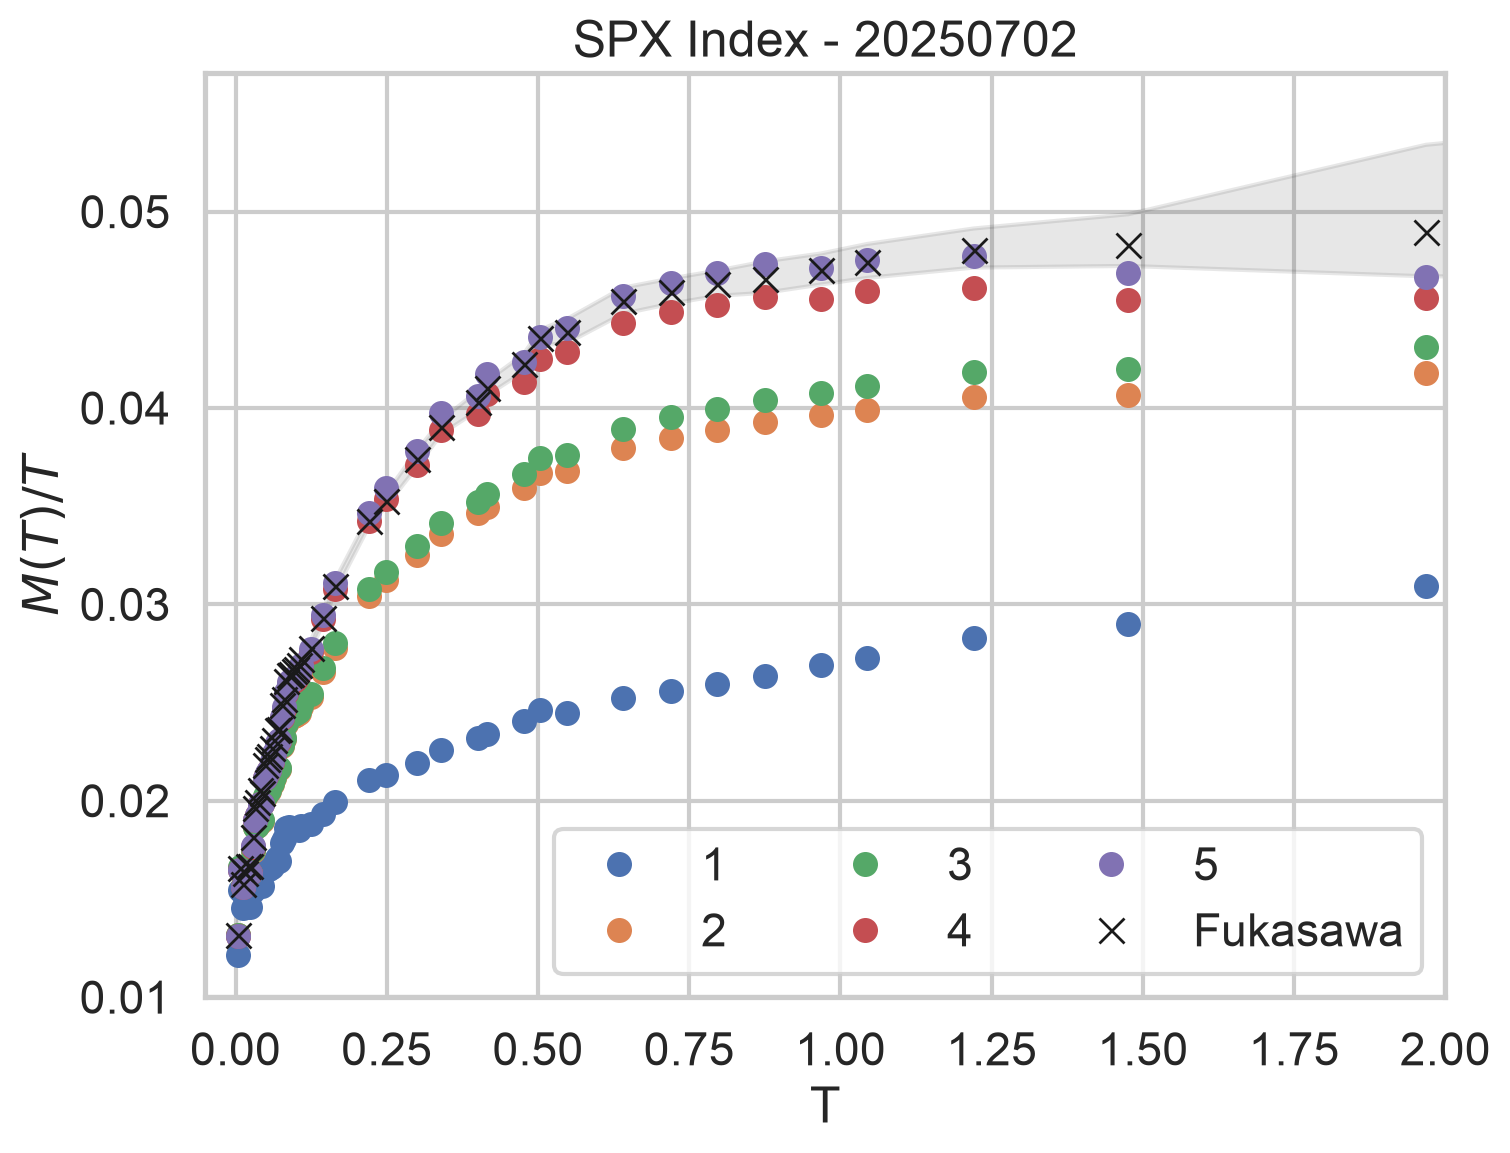

In [18]:
Ts = np.asarray(res["expiries"])
fig, ax = plt.subplots()
# magic strikes
for order in [1, 2, 3, 4, 5]:
    ax.plot(
        Ts,
        res["vs_mid_magic"][order - 1] / Ts,
        ".",
        markersize=16,
        label=f"{order}",
    )
# fukasawa
ax.plot(
    Ts,
    res["vs_mid"] / Ts,
    "kx",
    label="Fukasawa",
)
ax.fill_between(Ts, res["vs_bid"] / Ts, res["vs_ask"] / Ts, color="k", alpha=0.1)
ax.set_xlim(-0.05, 2.0)
ax.legend(ncol=3)
ax.set_xlabel("T")
ax.set_ylabel("$M(T)/T$")
ax.set_title(f"SPX Index - {date}")
if SAVEFIG:
    fig.savefig(f"figures/spx_{date}_vs.pdf", bbox_inches="tight")
plt.show()

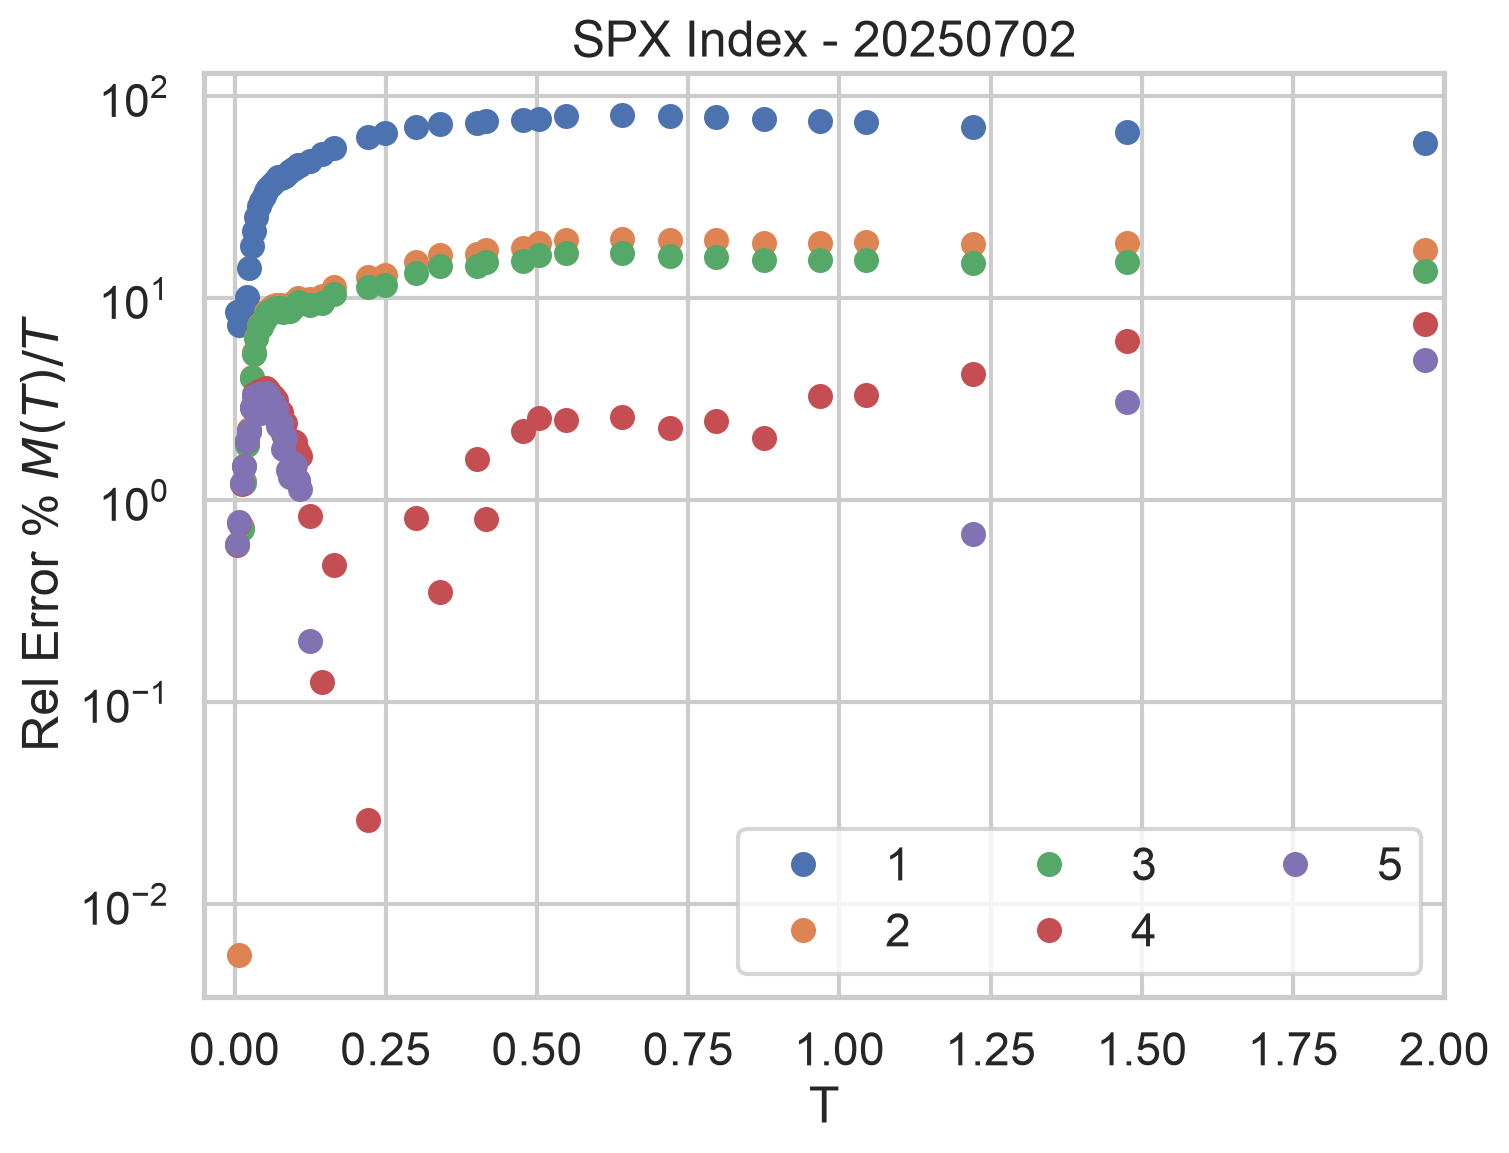

In [7]:
# relative error

Ts = np.asarray(res["expiries"])
ref_values = res["vs_mid"] / Ts

fig, ax = plt.subplots()
# magic strikes
for order in [1, 2, 3, 4, 5]:
    mid_magic_order = res["vs_mid_magic"][order - 1] / Ts
    rel_error = 100 * relative_error(mid_magic_order, ref_values)
    ax.semilogy(Ts, rel_error, ".", markersize=16, label=f"{order}")

ax.set_xlim(-0.05, 2.0)
ax.legend(ncol=3)
ax.set_xlabel("T")
ax.set_ylabel("Rel Error % $M(T)/T$")
ax.set_title(f"SPX Index - {date}")
plt.show()

# Gamma contract

In [ ]:
res_all = swap_market(
    ivol_data=ivol_data,
    opt="all",
    n_quad=10,
    extrapolation="flat",
)

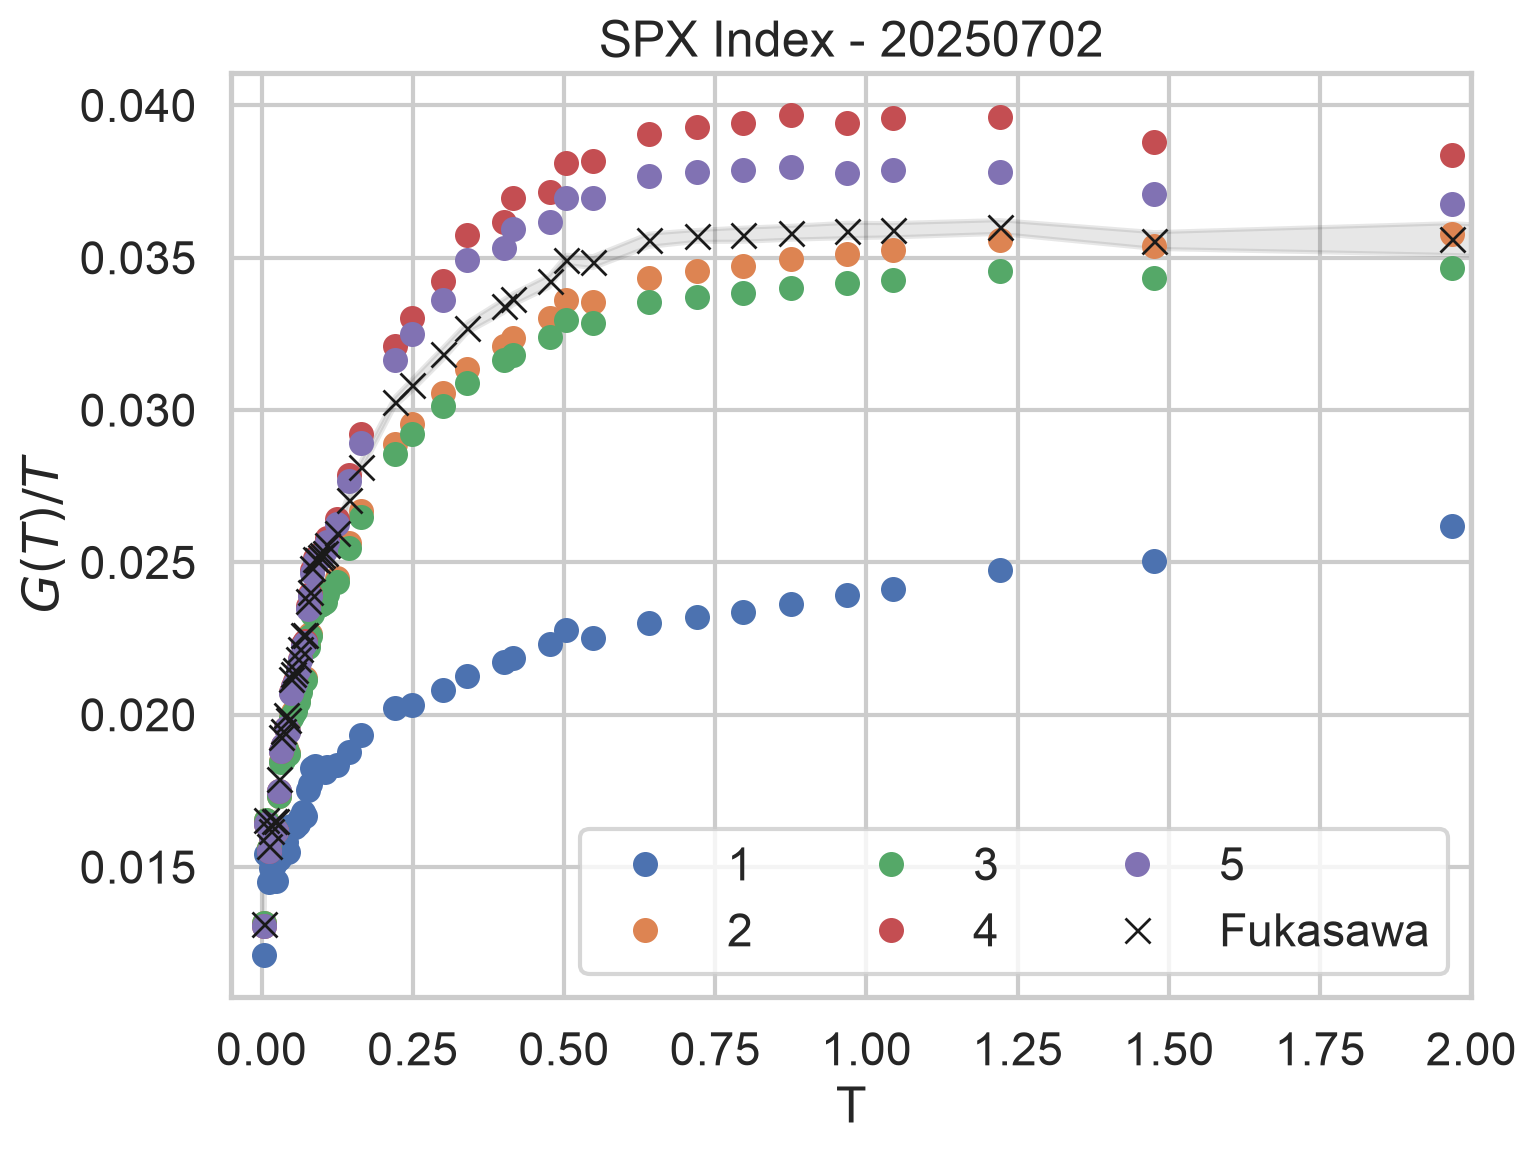

In [27]:
opt = "gamma"
Ts = res_all[opt]["expiries"]
ylabels = {
    "gamma": "$G(T)/T$",
}

fig, ax = plt.subplots()
# magic strikes
for order in [1, 2, 3, 4, 5]:
    ax.plot(
        Ts,
        res_all[opt][f"{opt}_mid_magic"][order - 1] / Ts,
        ".",
        markersize=16,
        label=f"{order}",
    )
# fukasawa
ax.plot(
    Ts,
    res_all[opt][f"{opt}_mid"] / Ts,
    "kx",
    label="Fukasawa",
)
ax.fill_between(
    Ts,
    res_all[opt][f"{opt}_bid"] / Ts,
    res_all[opt][f"{opt}_ask"] / Ts,
    color="k",
    alpha=0.1,
)
ax.set_xlim(-0.05, 2.0)
ax.legend(ncol=3)
ax.set_xlabel("T")
ax.set_ylabel(ylabels[opt])
ax.set_title(f"SPX Index - {date}")
if SAVEFIG:
    fig.savefig(f"figures/spx_{date}_{opt}.pdf", bbox_inches="tight")
plt.show()

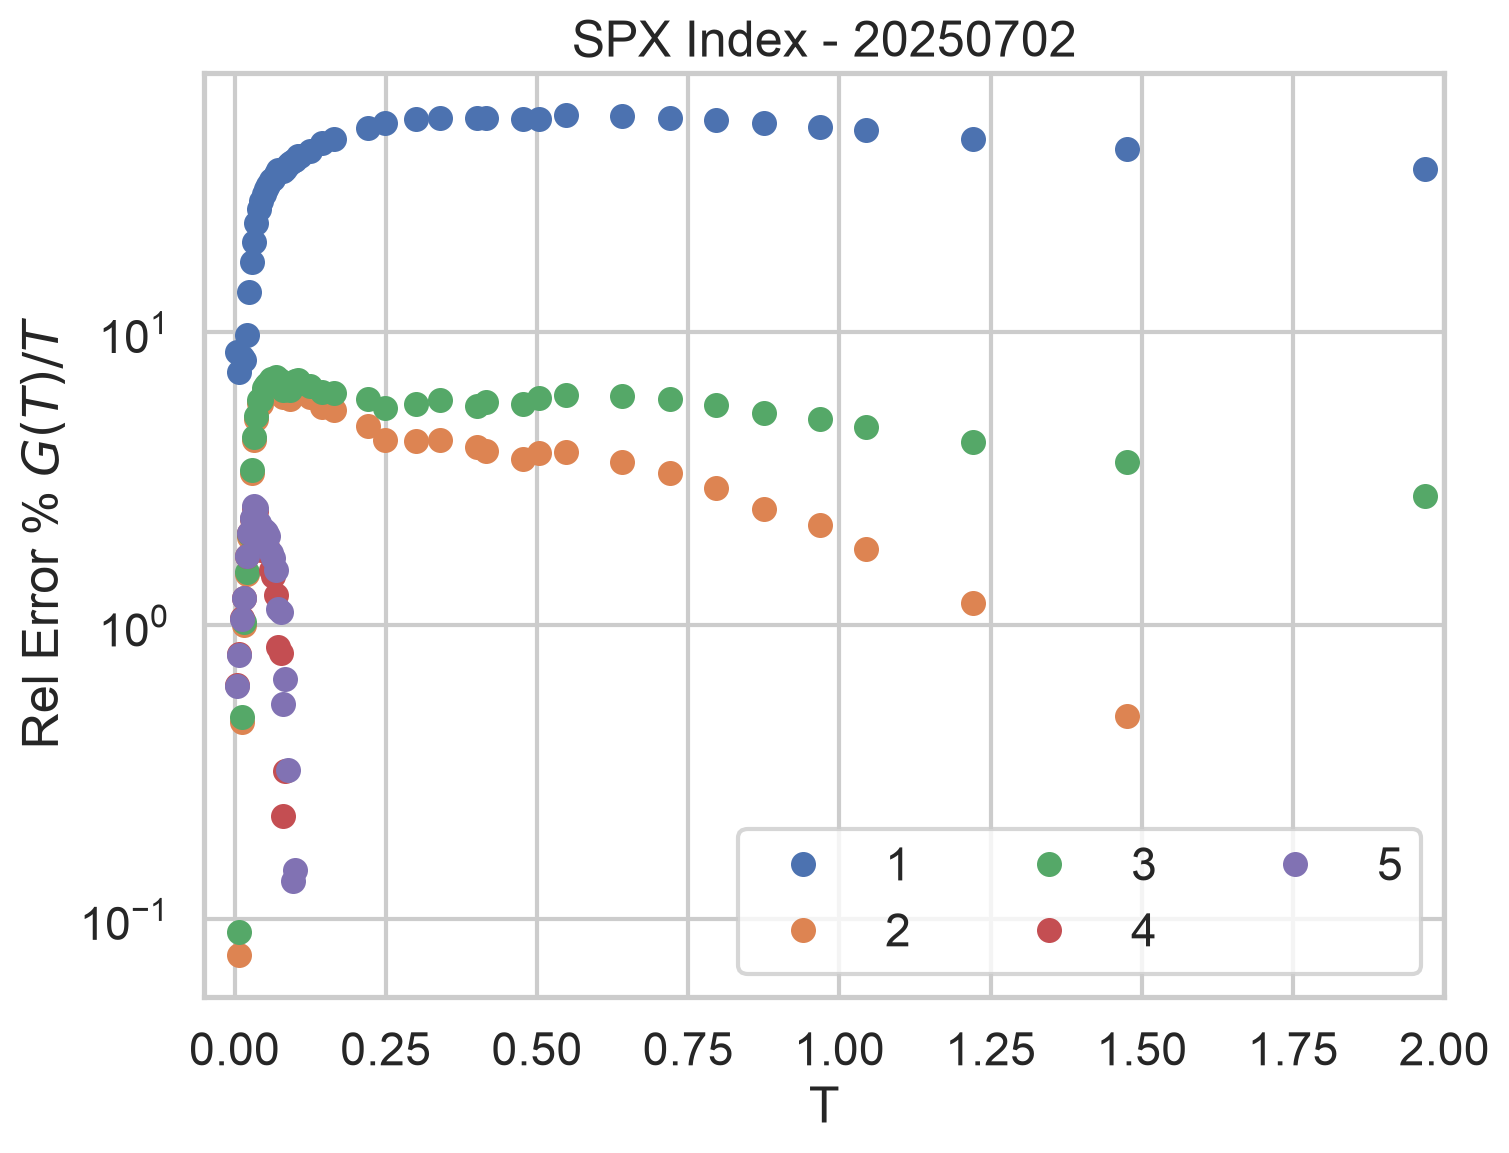

In [28]:
# relative error

opt = "gamma"
Ts = res_all[opt]["expiries"]
ylabels = {"gamma": r"$G(T)/T$"}

ref_values = res_all[opt][f"{opt}_mid"] / Ts

fig, ax = plt.subplots()
# magic strikes
for order in [1, 2, 3, 4, 5]:
    mid_magic_order = res_all[opt][f"{opt}_mid_magic"][order - 1] / Ts
    rel_error = 100 * relative_error(mid_magic_order, ref_values)
    ax.semilogy(Ts, rel_error, ".", markersize=16, label=f"{order}")

ax.set_xlim(-0.05, 2.0)
ax.legend(ncol=3)
ax.set_xlabel("T")
ax.set_ylabel(f"Rel Error % {ylabels[opt]}")
ax.set_title(f"SPX Index - {date}")
plt.show()